# DAGMC's CAD-Based Geometry in OpenMC

In [1]:
from IPython.display import Image
import openmc
import math
from matplotlib import pyplot as plt

In [2]:
import urllib.request

fuel_pin_url = 'https://tinyurl.com/y3ugwz6w' # 1.2 MB
teapot_url = 'https://tinyurl.com/y4mcmc3u' # 29 MB
paramak = 'https://tinyurl.com/4hpe4am3' # 3.9 MB
paramak_w_graveyard = 'https://tinyurl.com/y7w238th' # 18 MB

def download(url, filename="dagmc.h5m"):
    """
    Helper function for retrieving dagmc models
    """
    u = urllib.request.urlopen(url)

    if u.status != 200:
        raise RuntimeError("Failed to download file.")

    # save file as dagmc.h5m
    with open(filename, 'wb') as f:
        f.write(u.read())

Neat! But this pincell is something we could've done with CSG. Let's take a look at something more complex. We'll download a pre-built model of the [Utah teapot](https://en.wikipedia.org/wiki/Utah_teapot) and use it here.

In [3]:
teapot_model = openmc.Model()

In [4]:
download(teapot_url, "teapot.h5m")
dagmc_univ = openmc.DAGMCUniverse(filename="teapot.h5m")
teapot_model.geometry = openmc.Geometry(root=dagmc_univ)

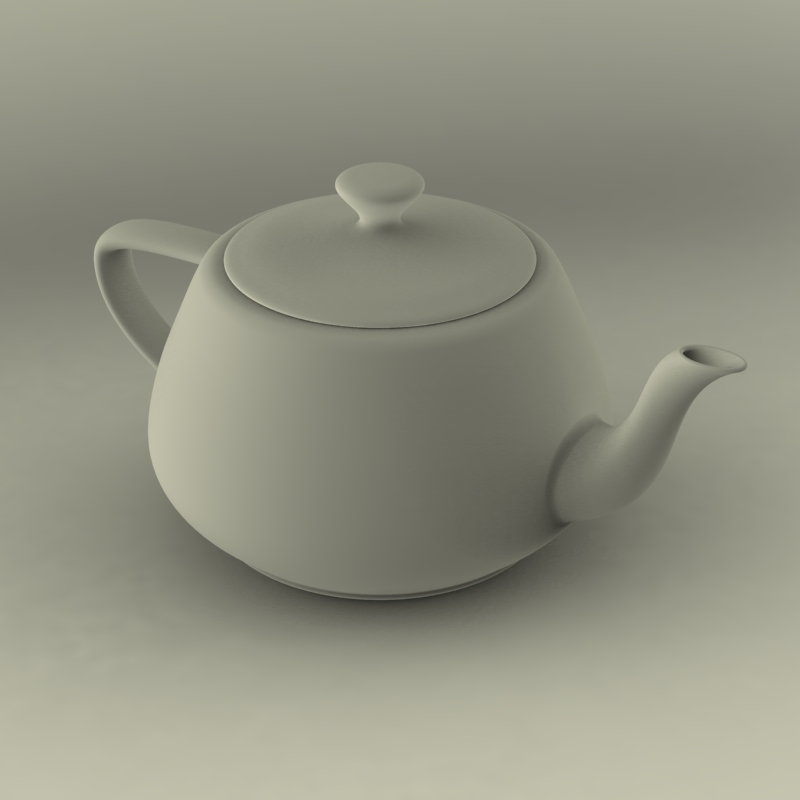

In [5]:
Image(filename="images/teapot.jpg", width=600)

Our teapot is made out of iron, so we'll want to create that material and make sure it is in our `materials.xml` file.

The DAGMC file contains tessellated surfaces that make up volumes. We can use built-in methods to inspect the geometry.

In [6]:
# returns the number of cells in the dagmc geometry
dagmc_univ.n_cells

5

In [7]:
# returns the number of surfaces in the dagmc geometry
dagmc_univ.n_surfaces

112

In [8]:
# returns the names of materials used in the geometry.
# these names are used when creating openmc.Materials
dagmc_univ.material_names

['Graveyard', 'iron', 'water']

In [9]:
iron = openmc.Material(name="iron")
iron.add_nuclide("Fe54", 0.0564555822608)
iron.add_nuclide("Fe56", 0.919015287728)
iron.add_nuclide("Fe57", 0.0216036861685)
iron.add_nuclide("Fe58", 0.00292544384231)
iron.set_density("g/cm3", 7.874)

water = openmc.Material(name="water")
water.add_nuclide('H1', 2.0, 'ao')
water.add_nuclide('O16', 1.0, 'ao')
water.set_density('g/cc', 1.0)
water.add_s_alpha_beta('c_H_in_H2O')
water.id = 41

teapot_model.materials = openmc.Materials([iron, water])

In [10]:
teapot_model.export_to_model_xml()

To make sure we've updated the file correctly, let's make a plot of the teapot.

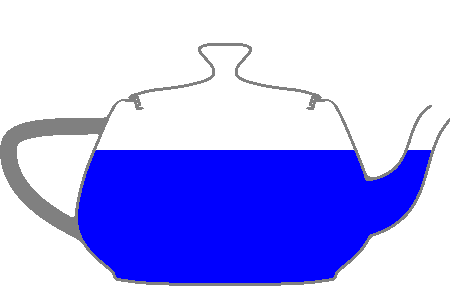

In [11]:
p = openmc.Plot()
p.basis = 'xz'
p.origin = (0.0, 0.0, 0.0)
p.width = (30.0, 20.0)
p.pixels = (450, 300)
p.color_by = 'material'
p.colors = {iron: 'gray', water: 'blue'}
openmc.plot_inline(p)

Here we start to see some of the advantages CAD geometries provide. This particular file was pulled from the [GrabCAD](https://grabcad.com/library) and pushed through the DAGMC workflow without modification (other than the addition of material assignments). It would take a considerable amount of time to create a model like this using CSG!

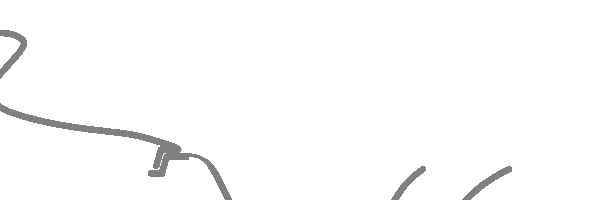

In [12]:
p.width = (18.0, 6.0)
p.basis = 'xz'
p.origin = (10.0, 0.0, 5.0)
p.pixels = (600, 200)
p.color_by = 'material'
openmc.plot_inline(p)

Now let's brew some tea! ... using a very hot neutron source. We'll use some well-placed point sources distributed throughout the model.

In [13]:
settings = openmc.Settings()
settings.batches = 10
settings.particles = 5000
settings.run_mode = "fixed source"

space = openmc.stats.Box(*teapot_model.geometry.bounding_box)
my_source = openmc.Source(space=space, domains=[water])
my_source.energy = openmc.stats.Discrete(x=[12.0,], p=[1.0,])

settings.source = my_source
teapot_model.settings = settings
teapot_model.export_to_model_xml()

/home/pshriwise/soft/openmc/openmc/source.py:656: FutureWarning: This class is deprecated in favor of 'IndependentSource'
  warnings.warn("This class is deprecated in favor of 'IndependentSource'", FutureWarning)
/home/pshriwise/soft/openmc/openmc/source.py:321: FutureWarning: The 'domains' arguments has been replaced by the 'constraints' argument.
  warnings.warn("The 'domains' arguments has been replaced by the "


...and setup a couple of mesh tallies. One for the kettle, and one for the water inside.

In [14]:
mesh = openmc.RegularMesh.from_domain(teapot_model.geometry, dimension=(120, 1, 120))
print(mesh)

mesh_filter = openmc.MeshFilter(mesh)

pot_filter = openmc.CellFilter([1])
pot_tally = openmc.Tally()
pot_tally.filters = [mesh_filter, pot_filter]
pot_tally.scores = ['flux']

water_filter = openmc.CellFilter([5])
water_tally = openmc.Tally()
water_tally.filters = [mesh_filter, water_filter]
water_tally.scores = ['flux']


teapot_model.tallies = openmc.Tallies([pot_tally, water_tally])

RegularMesh
	ID             =	1
	Name           =	
	Dimensions     =	3
	Voxels         =	(120, 1, 120)
	Lower left     =	[-25. -25. -25.]
	Upper Right    =	[25. 25. 25.]
	Width          =	None



In [15]:
sp_file = teapot_model.run()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

Note that the performance is significantly lower than our pincell model due to the increased complexity of the model, but it allows us to examine tally results like these:

In [16]:
with openmc.StatePoint(sp_file) as sp:
    pot_tally = sp.get_tally(scores=['flux'], id=pot_tally.id)
    water_tally = sp.get_tally(scores=['flux'], id=water_tally.id)

water_flux = water_tally.mean
water_flux = water_tally.get_reshaped_data(expand_dims=True).squeeze()

pot_flux = pot_tally.get_reshaped_data(expand_dims=True).squeeze()

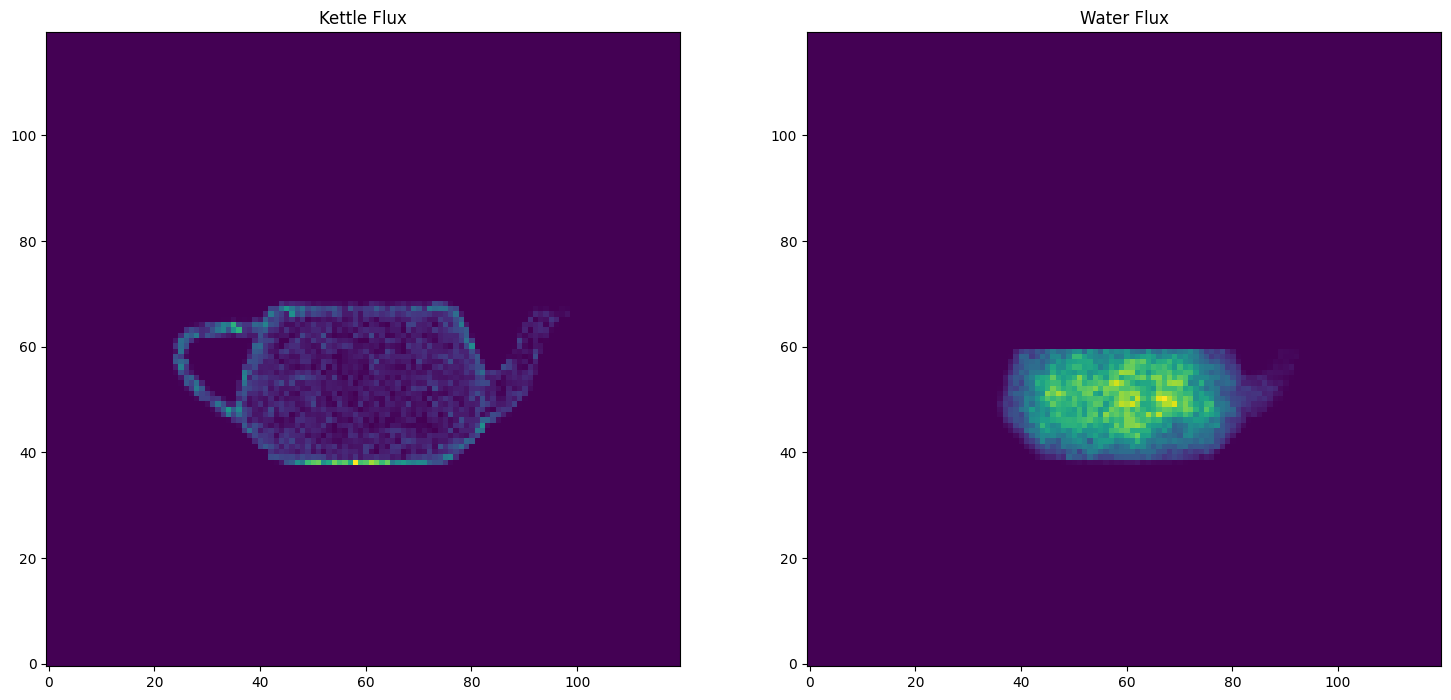

In [17]:
from matplotlib import pyplot as plt
fig = plt.figure(figsize=(18, 16))

sub_plot1 = plt.subplot(121, title="Kettle Flux")
sub_plot1.imshow(pot_flux.T)
sub_plot1.invert_yaxis()

sub_plot2 = plt.subplot(122, title="Water Flux")
sub_plot2.imshow(water_flux.T)
sub_plot2.invert_yaxis()

# Tokamak Geometry

Next we'll look at a tokamak model courtesy of John Shimwell's [paramak](https://github.com/fusion-energy/paramak) package.

In [18]:
tokamak_model = openmc.Model()

In [19]:
download(paramak_w_graveyard, 'paramak_with_graveyard.h5m')

In [20]:
dag_universe = openmc.DAGMCUniverse('paramak_with_graveyard.h5m')
tokamak_model.geometry = openmc.Geometry(root=dag_universe)

In [21]:
mat_pf_coil_1 = openmc.Material(name="pf_coil_1")
mat_pf_coil_1.add_element("Cu", 1, "ao")
mat_pf_coil_1.set_density("g/cm3", 8.96)
tokamak_model.materials.append(mat_pf_coil_1)

mat_pf_coil_2 = openmc.Material(name="pf_coil_2")
mat_pf_coil_2.add_element("Cu", 1, "ao")
mat_pf_coil_2.set_density("g/cm3", 8.96)
tokamak_model.materials.append(mat_pf_coil_2)

mat_pf_coil_3 = openmc.Material(name="pf_coil_3")
mat_pf_coil_3.add_element("Cu", 1, "ao")
mat_pf_coil_3.set_density("g/cm3", 8.96)
tokamak_model.materials.append(mat_pf_coil_3)

mat_pf_coil_4 = openmc.Material(name="pf_coil_4")
mat_pf_coil_4.add_element("Cu", 1, "ao")
mat_pf_coil_4.set_density("g/cm3", 8.96)
tokamak_model.materials.append(mat_pf_coil_4)

mat_plasma = openmc.Material(name="plasma")
mat_plasma.add_element("H", 1, "ao")
mat_plasma.set_density("g/cm3", 0.00001)
tokamak_model.materials.append(mat_plasma)

mat_inboard_tf_coils = openmc.Material(name="inboard_tf_coils")
mat_inboard_tf_coils.add_element("Cu", 1, "ao")
mat_inboard_tf_coils.set_density("g/cm3", 8.96)
tokamak_model.materials.append(mat_inboard_tf_coils)

mat_center_column_shield = openmc.Material(name="center_column_shield")
mat_center_column_shield.add_element("W", 1, "ao")
mat_center_column_shield.set_density("g/cm3", 19.3)
tokamak_model.materials.append(mat_center_column_shield)

mat_firstwall = openmc.Material(name="firstwall")
mat_firstwall.add_element("Fe", 1, "ao")
mat_firstwall.set_density("g/cm3", 7.7)
tokamak_model.materials.append(mat_firstwall)

mat_blanket = openmc.Material(name="blanket")
mat_blanket.add_elements_from_formula("Pb842Li158")
mat_blanket.set_density("g/cm3", 19.)
tokamak_model.materials.append(mat_blanket)

mat_blanket_rear_wall = openmc.Material(name="blanket_rear_wall")
mat_blanket_rear_wall.add_element("Fe", 1, "ao")
mat_blanket_rear_wall.set_density("g/cm3", 7.7)
tokamak_model.materials.append(mat_blanket_rear_wall)

mat_divertor_upper = openmc.Material(name="divertor_upper")
mat_divertor_upper.add_element("W", 1, "ao")
mat_divertor_upper.set_density("g/cm3", 19.3)
tokamak_model.materials.append(mat_divertor_upper)

mat_divertor_lower = openmc.Material(name="divertor_lower")
mat_divertor_lower.add_element("W", 1, "ao")
mat_divertor_lower.set_density("g/cm3", 19.3)
tokamak_model.materials.append(mat_divertor_lower)

mat_pf_coil_case_1 = openmc.Material(name="pf_coil_case_1")
mat_pf_coil_case_1.add_element("Fe", 1, "ao")
mat_pf_coil_case_1.set_density("g/cm3", 8.96)
tokamak_model.materials.append(mat_pf_coil_case_1)

mat_pf_coil_case_2 = openmc.Material(name="pf_coil_case_2")
mat_pf_coil_case_2.add_element("Fe", 1, "ao")
mat_pf_coil_case_2.set_density("g/cm3", 8.96)
tokamak_model.materials.append(mat_pf_coil_case_2)

mat_pf_coil_case_3 = openmc.Material(name="pf_coil_case_3")
mat_pf_coil_case_3.add_element("Fe", 1, "ao")
mat_pf_coil_case_3.set_density("g/cm3", 8.96)
tokamak_model.materials.append(mat_pf_coil_case_3)

mat_pf_coil_case_4 = openmc.Material(name="pf_coil_case_4")
mat_pf_coil_case_4.add_element("Fe", 1, "ao")
mat_pf_coil_case_4.set_density("g/cm3", 8.96)
tokamak_model.materials.append(mat_pf_coil_case_4)


In [22]:
# creates a simple isotropic neutron source in the center with 14MeV neutrons
source = openmc.Source()
# the distribution of radius is just a single value at the plasma major radius
radius = openmc.stats.Discrete([250.], [1])
# the distribution of source z values is just a single value
z_values = openmc.stats.Discrete([0], [1])
# the distribution of source azimuthal angles values is a uniform distribution between 0 and 0.5 Pi
# these angles must be the same as the reflective angles
angle = openmc.stats.Uniform(a=0., b=math.radians(180))
# this makes the ring source using the three distributions and a radius
source.space = openmc.stats.CylindricalIndependent(r=radius, phi=angle, z=z_values, origin=(0.0, 0.0, 0.0))
# sets the direction to isotropic
source.angle = openmc.stats.Isotropic()
# sets the energy distribution to a Muir distribution neutrons
source.energy = openmc.muir(e0=14080000.0, m_rat=5.0, kt=20000.0)

/home/pshriwise/soft/openmc/openmc/source.py:656: FutureWarning: This class is deprecated in favor of 'IndependentSource'
  warnings.warn("This class is deprecated in favor of 'IndependentSource'", FutureWarning)
/home/pshriwise/soft/openmc/openmc/stats/univariate.py:820: FutureWarning: The Muir(...) class has been replaced by the muir(...) function and will be removed in a future version of OpenMC. Use muir(...) instead.
  warn(


In [23]:
tokamak_model.settings.run_mode = 'fixed source'
tokamak_model.settings.source = source
tokamak_model.settings.batches = 10
tokamak_model.settings.particles = 10000

In [24]:
mesh = openmc.RegularMesh().from_domain(tokamak_model.geometry, dimension=(100,100,100))

mesh_filter = openmc.MeshFilter(mesh)

material_filter = openmc.MaterialFilter([mat_blanket])

flux_tally = openmc.Tally(name='blanket flux')
flux_tally.filters = [mesh_filter, material_filter]
flux_tally.scores = ['flux']
tokamak_model.tallies = openmc.Tallies([flux_tally])

In [25]:
tokamak_model.export_to_model_xml()

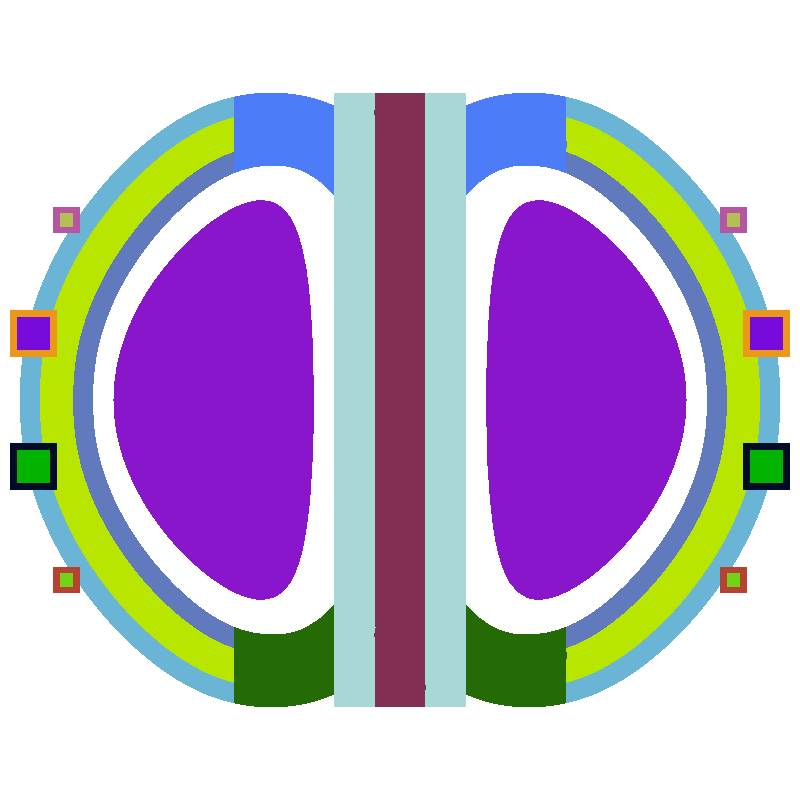

In [26]:
p = openmc.Plot()
p.origin = (0, 10, 0)
p.pixels = (800, 800)
p.width = (1200, 1200)
p.basis = 'xz'
p.color_by = 'material'
openmc.plot_inline([p])

In [27]:
sp_filename = tokamak_model.run()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

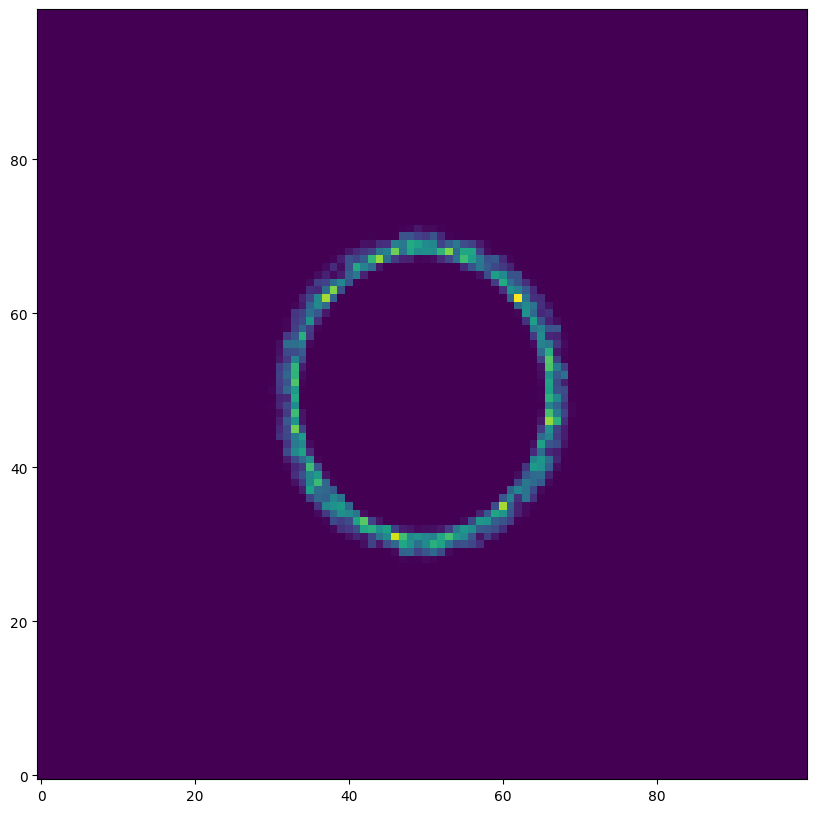

In [28]:
with openmc.StatePoint(sp_filename) as sp:
    flux_tally = sp.get_tally(name='blanket flux')

flux_mean = flux_tally.get_reshaped_data(expand_dims=True).squeeze()
plt.figure(figsize=(10,10))
plt.imshow(flux_mean[:, 50, :], origin='lower')

In [29]:
x_min = openmc.XPlane(0.0, boundary_type='reflective')
x_max = openmc.XPlane(600.0, boundary_type='vacuum')

y_min = openmc.YPlane(0.0, boundary_type='reflective')
y_max = openmc.YPlane(600.0, boundary_type='vacuum')

region = +x_min & -x_max & +y_min & -y_max
quarter_cell = openmc.Cell(fill=dag_universe, region=region)
dag_universe.auto_geom_ids = True

tokamak_model.geometry = openmc.Geometry([quarter_cell])

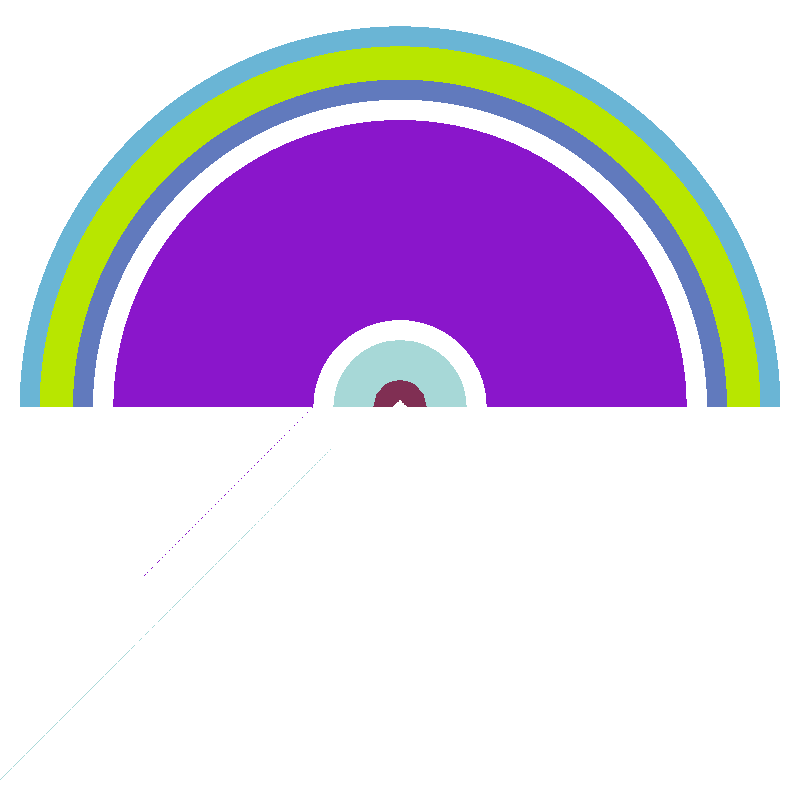

In [30]:
p.basis = 'xy'
openmc.plot_inline(p)

In [31]:
z_min = openmc.ZPlane(-0.1, boundary_type='reflective')
quarter_cell.region &= +z_min

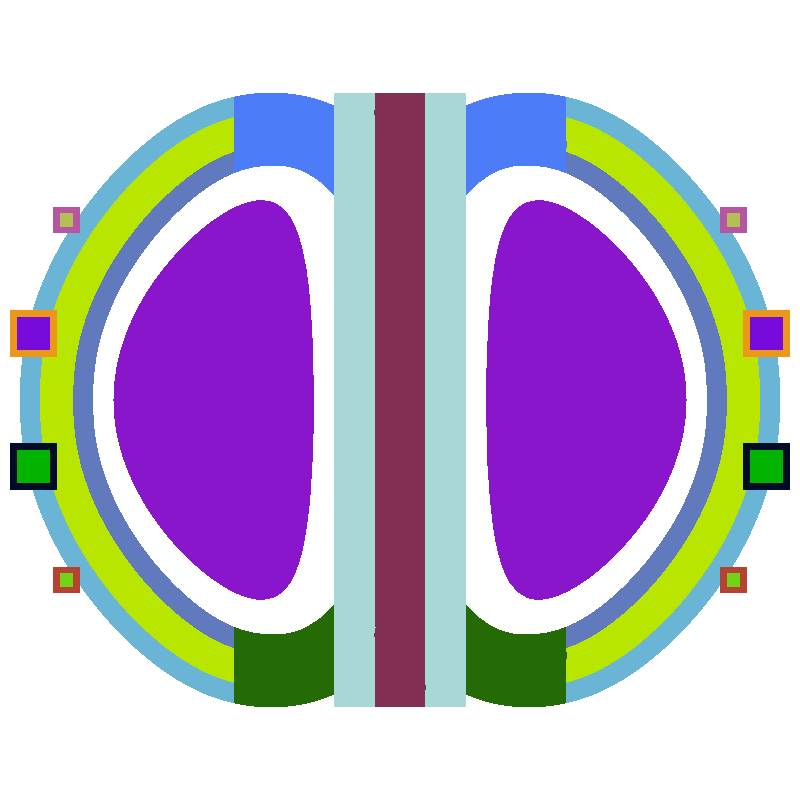

In [32]:
tokamak_model.export_to_xml()
p.basis = 'xz'
openmc.plot_inline(p)

In [33]:
mesh = openmc.RegularMesh()
mesh.lower_left = [0,  0.0, 0]
mesh.upper_right = [500, 500, 500]
mesh.dimension = (200, 200, 200)

mesh_filter = openmc.MeshFilter(mesh)

material_filter = openmc.MaterialFilter([mat_blanket])

flux_tally = openmc.Tally(name='blanket flux')
flux_tally.filters = [mesh_filter, material_filter]
flux_tally.scores = ['flux']

tokamak_model.tallies = [flux_tally]

In [34]:
sp_filename = tokamak_model.run()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

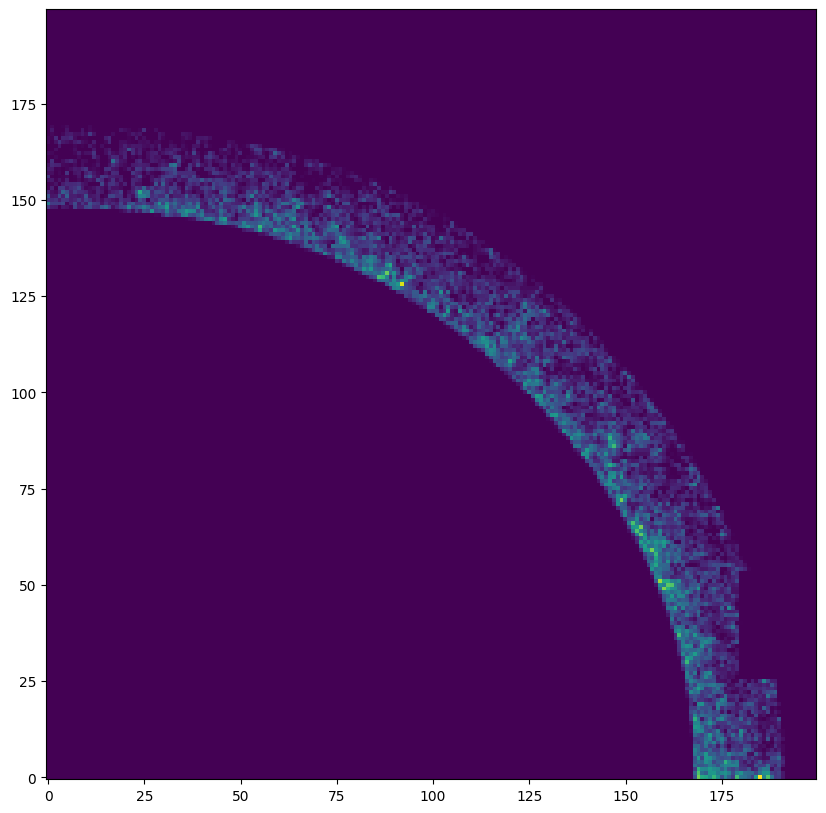

In [35]:
with openmc.StatePoint(sp_filename) as sp:
    flux_tally = sp.get_tally(name='blanket flux')

flux_mean = flux_tally.mean.reshape(*mesh.dimension)
plt.figure(figsize=(10,10))
plt.imshow(flux_mean[:, 100, :], origin='lower')

In [36]:
x_min = openmc.XPlane(-650.0, boundary_type='vacuum')
x_max = openmc.XPlane(650.0, boundary_type='vacuum')

y_min = openmc.YPlane(-650.0, boundary_type='vacuum')
y_max = openmc.YPlane(650.0, boundary_type='vacuum')

z_min = openmc.ZPlane(-650.0, boundary_type='vacuum')
z_max = openmc.ZPlane(650.0, boundary_type='vacuum')

y0 = openmc.YPlane(0.0)

c_upper = openmc.Cell(fill=dag_universe, region=+x_min & -x_max & +y0 & -y_max & +z_min & -z_max)
c_lower = openmc.Cell(fill=dag_universe, region=+x_min & -x_max & +y_min & -y0 & +z_min & -z_max)
c_lower.rotation = (0.0, 0.0, 180.0)

dag_universe.auto_geom_ids = True
geometry = openmc.Geometry([c_upper, c_lower])
tokamak_model.geometry = geometry

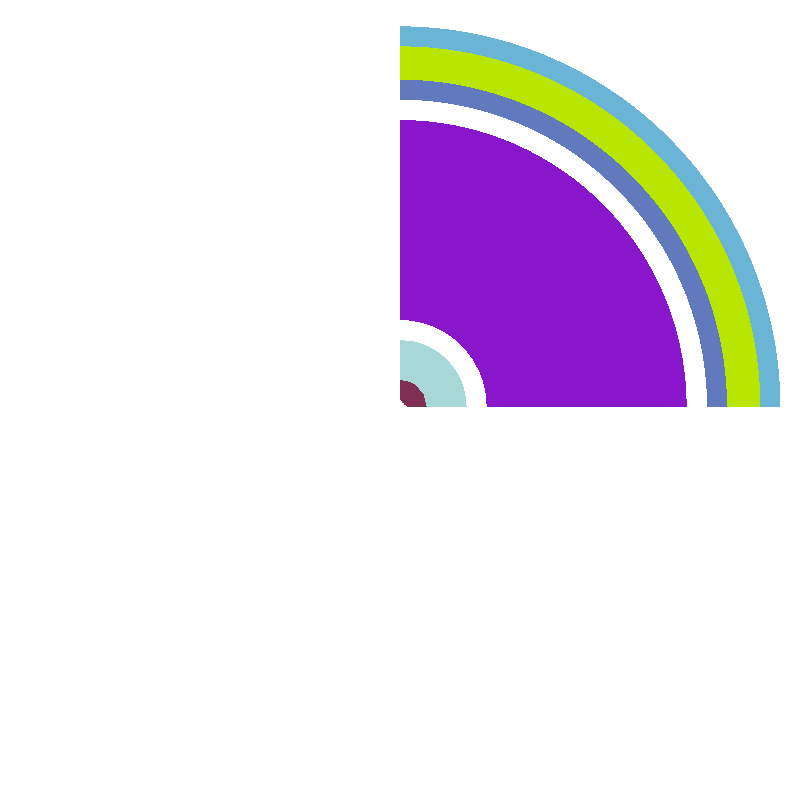

In [37]:
teapot_model.export_to_xml()
p.basis = 'xy'
openmc.plot_inline(p)

In [39]:
sp_filename = tokamak_model.run()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################